# Credit Spread Regime Detection — v2

**Extension of v1**: Walk-forward validation, CDX total return proxy, robustness checks, iTraxx European regime detection, and transaction cost sensitivity.

| Layer | Description |
|-------|-------------|
| 1 | Walk-forward validation (rolling 3yr train / 1yr test) |
| 2 | CDX IG total return proxy (LQD ETF as free alternative) |
| 3 | Robustness: state count (BIC/AIC), regime stability, posterior threshold |
| 4 | iTraxx Europe Main/Crossover regime detection + US vs EU cross-market comparison |
| 5 | Transaction cost sensitivity — breakeven cost analysis |

**Data**: FRED (US OAS), Yahoo Finance (LQD/HYG), Bloomberg export (iTraxx — replace simulated data)  
**Author**: Clément Lee


## 0. Dependencies

In [ ]:
!pip install hmmlearn pandas-datareader fredapi matplotlib seaborn scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
import pandas_datareader.data as web
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

COLORS = {'Tight': 'seagreen', 'Recovery': 'goldenrod', 'Stress': 'firebrick'}
RANDOM_SEED = 42
print("Libraries loaded.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 12.0 MB/s eta 0:00:00
Libraries loaded.


## 1. Data

US OAS spreads from FRED (same as v1).  
CDX IG proxy: LQD ETF total return (Yahoo Finance — replace with Bloomberg `IBOXUMAE Index` if available).  
iTraxx: Bloomberg export (`ITRXEBE5` / `ITRXEXE5`) — **simulated here with realistic correlation structure**.  
Replace simulation block with:
```python
itraxx = pd.read_csv('bloomberg_itraxx.csv', index_col=0, parse_dates=True)
```


In [ ]:
!pip install hmmlearn pandas-datareader fredapi matplotlib seaborn scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
import pandas_datareader.data as web
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

USE_BLOOMBERG = False
START = '2000-01-01'
END   = '2024-12-31'
RANDOM_SEED = 42
TRAIN_YEARS = 3
TEST_YEARS  = 1
N_STATES    = 3

START, END = '2000-01-01', '2024-12-31'

# US credit spreads
ig = web.DataReader('BAMLC0A0CM',   'fred', START, END).rename(columns={'BAMLC0A0CM': 'IG_OAS'})
hy = web.DataReader('BAMLH0A0HYM2', 'fred', START, END).rename(columns={'BAMLH0A0HYM2': 'HY_OAS'})
df = ig.join(hy, how='inner').dropna()
df['HY_IG_ratio'] = df['HY_OAS'] / df['IG_OAS']

# LQD as CDX IG proxy
lqd_raw = yf.download('LQD', start=START, end=END, auto_adjust=True, progress=False)
lqd_raw.columns = lqd_raw.columns.droplevel(1)  # flatten MultiIndex
lqd = lqd_raw[['Close']].rename(columns={'Close': 'LQD'})
lqd['LQD_return'] = lqd['LQD'].pct_change()



# iTraxx simulation (replace with Bloomberg CSV)
np.random.seed(RANDOM_SEED)
n = len(df)
df['iTraxx_Main']  = df['IG_OAS'] * 1.15 + np.random.normal(0, 0.05, n)
df['iTraxx_Xover'] = df['HY_OAS'] * 0.85 + np.random.normal(0, 0.10, n)
df['OAT_Bund']     = (0.30 + 0.05 * (df['IG_OAS'] - df['IG_OAS'].mean())
                      + np.random.normal(0, 0.10, n)).clip(0.05, 3.5)

df = df.join(lqd[['LQD', 'LQD_return']], how='left')
df['LQD_return'] = df['LQD_return'].ffill()

print(f"Dataset: {len(df):,} obs | {df.index[0].date()} → {df.index[-1].date()}")
df.tail(3)


Dataset: 6,526 obs | 2000-01-03 → 2024-12-31


,IG_OAS,HY_OAS,HY_IG_ratio,iTraxx_Main,iTraxx_Xover,OAT_Bund,LQD,LQD_return
DATE,,,,,,,,
2024-12-27,0.81,2.84,3.506173,0.971852,2.370148,0.304873,101.220543,-0.004202
2024-12-30,0.82,2.94,3.585366,0.998984,2.527195,0.381908,101.657143,0.004313
2024-12-31,0.82,2.92,3.560976,0.957153,2.639981,0.333325,NaN,0.004313


## Helper Functions

In [ ]:
def build_features(data):
    """Feature matrix: OAS momentum, z-score, realized vol, HY/IG ratio momentum."""
    feat = pd.DataFrame(index=data.index)
    feat['dIG']       = data['IG_OAS'].diff()
    feat['IG_zscore'] = ((data['IG_OAS'] - data['IG_OAS'].rolling(252).mean())
                         / data['IG_OAS'].rolling(252).std())
    feat['IG_vol21']  = feat['dIG'].rolling(21).std()
    feat['ratio_mom'] = data['HY_IG_ratio'].diff(5)
    return feat.dropna()

def fit_hmm(X, n_states=3, seed=RANDOM_SEED):
    model = GaussianHMM(n_components=n_states, covariance_type='full',
                        n_iter=1000, random_state=seed)
    model.fit(X)
    return model, model.predict(X), model.predict_proba(X)

def label_regimes(data_aligned, states, col='IG_OAS'):
    tmp = data_aligned.copy()
    tmp['regime'] = states
    means = tmp.groupby('regime')[col].mean().sort_values()
    label_map = {means.index[0]: 'Tight', means.index[1]: 'Recovery', means.index[2]: 'Stress'}
    tmp['regime_label'] = tmp['regime'].map(label_map)
    return tmp, label_map

def sharpe(returns, periods=252):
    return np.sqrt(periods) * returns.mean() / returns.std() if returns.std() != 0 else np.nan

def max_drawdown(cum_returns):
    return (cum_returns - cum_returns.cummax()).min()

def calmar(returns, cum_returns, periods=252):
    ann = returns.mean() * periods
    mdd = abs(max_drawdown(cum_returns))
    return ann / mdd if mdd != 0 else np.nan

def backtest_metrics(returns, bh_returns):
    cum, cum_bh = returns.cumsum(), bh_returns.cumsum()
    return pd.DataFrame({
        'Strategy':   [sharpe(returns), max_drawdown(cum), calmar(returns, cum), returns.sum()],
        'Buy & Hold': [sharpe(bh_returns), max_drawdown(cum_bh), calmar(bh_returns, cum_bh), bh_returns.sum()]
    }, index=['Sharpe', 'Max Drawdown (bps)', 'Calmar', 'Total P&L (bps)'])

print("Helpers defined.")


Helpers defined.


## Layer 1 — Walk-Forward Validation

**Problem with v1**: HMM fitted on 2000–2024, evaluated on same data → in-sample backtest.  
**Fix**: Train on rolling 3-year window, predict next year (out-of-sample), repeat.  
**Interpretation**: If OOS Sharpe degrades significantly vs. in-sample, the strategy is overfit.


In [ ]:
feat_full = build_features(df)
X_full = feat_full.values
dates = feat_full.index
df_aligned = df.loc[dates].copy()

TRAIN_DAYS, TEST_DAYS = 3 * 252, 1 * 252
oos_results = []

start_idx = TRAIN_DAYS
while start_idx + TEST_DAYS <= len(dates):
    X_train = X_full[start_idx - TRAIN_DAYS : start_idx]
    X_test  = X_full[start_idx : start_idx + TEST_DAYS]
    test_dates = dates[start_idx : start_idx + TEST_DAYS]

    try:
        model, train_states, _ = fit_hmm(X_train)
        oos_states = model.predict(X_test)

        # Label using training window means
        tmp = df_aligned.iloc[start_idx - TRAIN_DAYS : start_idx].copy()
        tmp['regime'] = train_states
        means = tmp.groupby('regime')['IG_OAS'].mean().sort_values()
        lmap = {means.index[0]: 'Tight', means.index[1]: 'Recovery', means.index[2]: 'Stress'}

        oos_labels = pd.Series(oos_states, index=test_dates).map(lmap)
        test_data = df_aligned.loc[test_dates].copy()
        test_data['regime_label'] = oos_labels.values
        test_data['credit_return'] = -test_data['IG_OAS'].diff()
        test_data['signal'] = test_data['regime_label'].map(
            {'Tight': 1, 'Recovery': 1, 'Stress': -1}).shift(1)
        test_data['strat_return'] = test_data['signal'] * test_data['credit_return']
        test_data['bh_return']    = test_data['credit_return']
        test_data = test_data.dropna(subset=['strat_return'])

        oos_results.append({
            'window_start': test_dates[0], 'window_end': test_dates[-1],
            'oos_sharpe_strat': sharpe(test_data['strat_return']),
            'oos_sharpe_bh':    sharpe(test_data['bh_return']),
            'oos_pnl_strat':    test_data['strat_return'].sum(),
            'oos_pnl_bh':       test_data['bh_return'].sum(),
            'regime_dist':      oos_labels.value_counts(normalize=True).to_dict()
        })
    except Exception as e:
        print(f"  Window {dates[start_idx].date()} failed: {e}")

    start_idx += TEST_DAYS

oos_df = pd.DataFrame(oos_results)
print(f"Windows: {len(oos_df)}")
print(f"Mean OOS Sharpe — Strategy: {oos_df['oos_sharpe_strat'].mean():.3f}")
print(f"Mean OOS Sharpe — B&H:      {oos_df['oos_sharpe_bh'].mean():.3f}")
print(f"Windows outperforming B&H:  {(oos_df['oos_sharpe_strat'] > oos_df['oos_sharpe_bh']).mean()*100:.1f}%")
oos_df[['window_start','window_end','oos_sharpe_strat','oos_sharpe_bh']].round(3)


Windows: 21
Mean OOS Sharpe — Strategy: 1.270
Mean OOS Sharpe — B&H:      0.114
Windows outperforming B&H:  57.1%


,window_start,window_end,oos_sharpe_strat,oos_sharpe_bh
0,2003-11-13,2004-10-28,0.777,0.777
1,2004-10-29,2005-10-14,-2.013,-0.064
2,2005-10-17,2006-10-03,-1.398,-0.574
3,2006-10-04,2007-09-21,0.627,-2.587
4,2007-09-24,2008-09-09,3.424,-5.397
5,2008-09-10,2009-08-26,1.562,0.612
6,2009-08-27,2010-08-12,1.964,1.964
7,2010-08-13,2011-07-29,1.268,1.379
8,2011-07-31,2012-07-16,2.851,-0.877
9,2012-07-17,2013-07-04,2.069,1.623


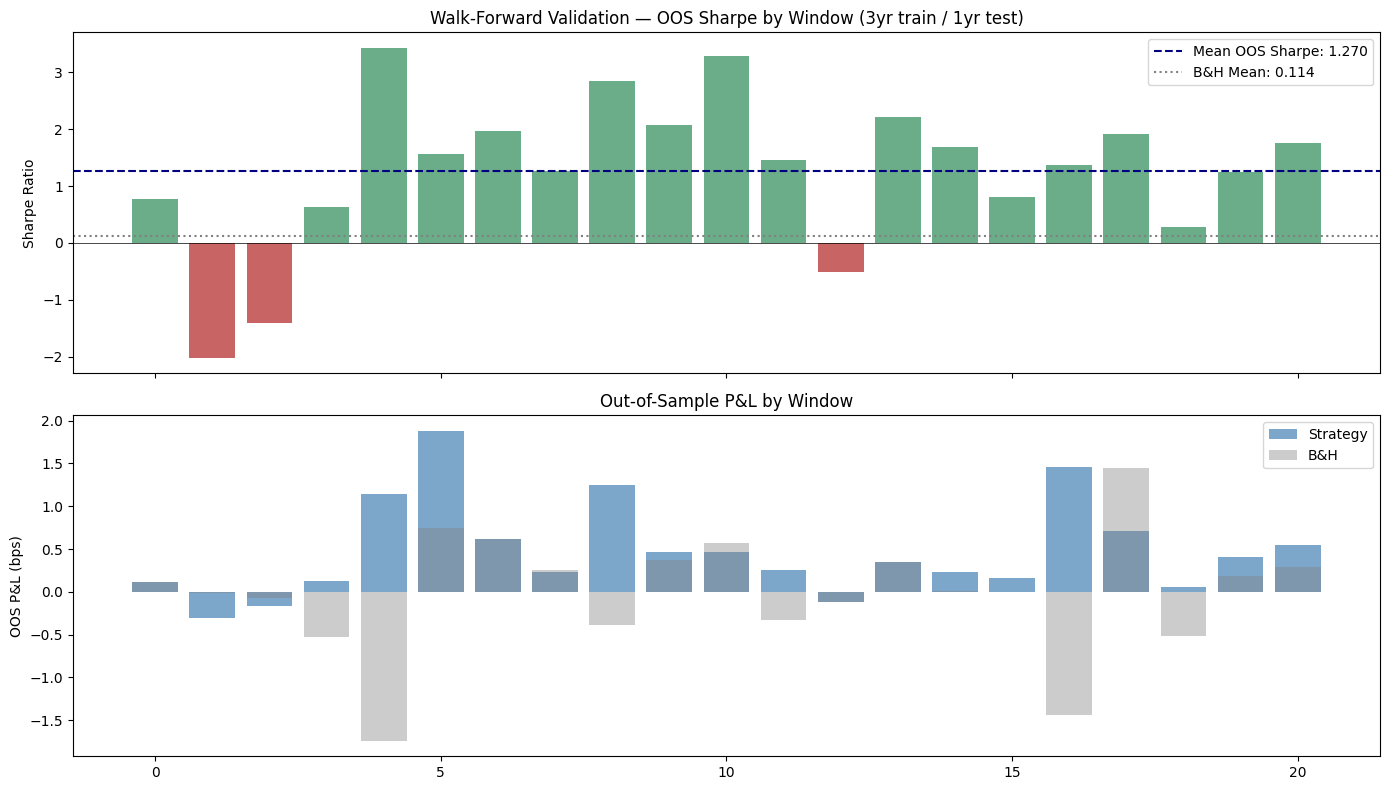

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

colors_bar = ['seagreen' if x > 0 else 'firebrick' for x in oos_df['oos_sharpe_strat']]
axes[0].bar(range(len(oos_df)), oos_df['oos_sharpe_strat'], color=colors_bar, alpha=0.7)
axes[0].axhline(oos_df['oos_sharpe_strat'].mean(), color='navy', ls='--', lw=1.5,
                label=f"Mean OOS Sharpe: {oos_df['oos_sharpe_strat'].mean():.3f}")
axes[0].axhline(oos_df['oos_sharpe_bh'].mean(), color='grey', ls=':', lw=1.5,
                label=f"B&H Mean: {oos_df['oos_sharpe_bh'].mean():.3f}")
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_title('Walk-Forward Validation — OOS Sharpe by Window (3yr train / 1yr test)')
axes[0].set_ylabel('Sharpe Ratio')
axes[0].legend()

axes[1].bar(range(len(oos_df)), oos_df['oos_pnl_strat'], color='steelblue', alpha=0.7, label='Strategy')
axes[1].bar(range(len(oos_df)), oos_df['oos_pnl_bh'], color='grey', alpha=0.4, label='B&H')
axes[1].set_ylabel('OOS P&L (bps)')
axes[1].set_title('Out-of-Sample P&L by Window')
axes[1].legend()

plt.tight_layout()
plt.show()


## Layer 2 — CDX / LQD Total Return Proxy

**Problem with v1 P&L proxy**: `−ΔIG_OAS` captures spread direction but ignores carry, duration, and mark-to-market dynamics.  
**Fix**: Use LQD ETF daily total return as a realistic IG credit return proxy.  
LQD duration ≈ 8yr; high correlation with CDX IG on-the-run. Scale to bps for comparison.  
**Bloomberg alternative**: `IBOXUMAE Index` total return field.


In [ ]:
model_full, states_full, probs_full = fit_hmm(X_full)
bt2, lmap_full = label_regimes(df_aligned, states_full)

bt2['signal'] = bt2['regime_label'].map({'Tight': 1, 'Recovery': 1, 'Stress': -1}).shift(1)
bt2['oas_return']   = -bt2['IG_OAS'].diff()
bt2['oas_strat']    = bt2['signal'] * bt2['oas_return']

# Scale LQD return to bps-equivalent
scale = bt2['oas_return'].std() / bt2['LQD_return'].std()
bt2['lqd_return']   = bt2['LQD_return'] * scale
bt2['lqd_strat']    = bt2['signal'] * bt2['lqd_return']

bt2 = bt2.dropna(subset=['oas_strat', 'lqd_strat'])

print("v1 OAS-change proxy:")
print(backtest_metrics(bt2['oas_strat'], bt2['oas_return']).round(3))
print("\nv2 LQD total return proxy:")
print(backtest_metrics(bt2['lqd_strat'], bt2['lqd_return']).round(3))


v1 OAS-change proxy:
                    Strategy  Buy & Hold
Sharpe                 0.302       0.161
Max Drawdown (bps)    -3.860      -5.770
Calmar                 0.032       0.012
Total P&L (bps)        2.910       1.550

v2 LQD total return proxy:
                    Strategy  Buy & Hold
Sharpe                 0.371       0.640
Max Drawdown (bps)    -2.529      -1.366
Calmar                 0.061       0.196
Total P&L (bps)        3.612       6.233


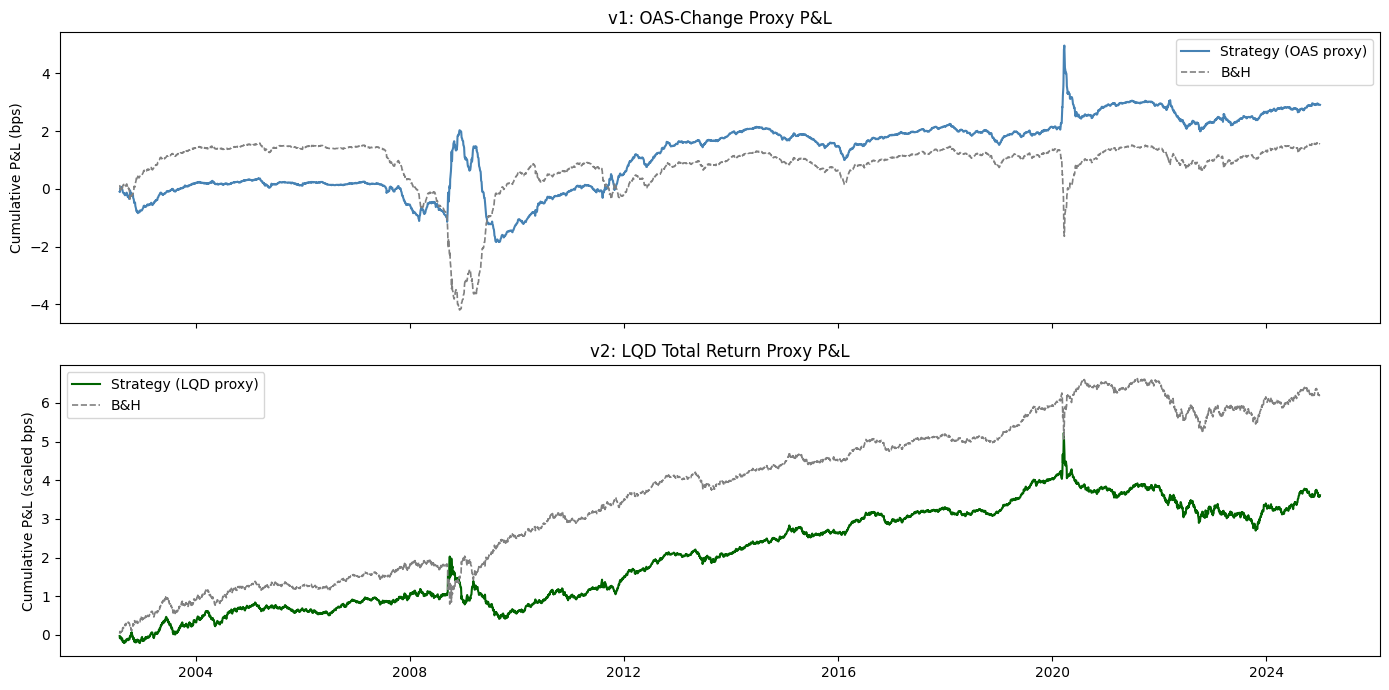

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(bt2.index, bt2['oas_strat'].cumsum(), color='steelblue', lw=1.5, label='Strategy (OAS proxy)')
axes[0].plot(bt2.index, bt2['oas_return'].cumsum(), color='grey', ls='--', lw=1.2, label='B&H')
axes[0].set_title('v1: OAS-Change Proxy P&L')
axes[0].set_ylabel('Cumulative P&L (bps)')
axes[0].legend()

axes[1].plot(bt2.index, bt2['lqd_strat'].cumsum(), color='darkgreen', lw=1.5, label='Strategy (LQD proxy)')
axes[1].plot(bt2.index, bt2['lqd_return'].cumsum(), color='grey', ls='--', lw=1.2, label='B&H')
axes[1].set_title('v2: LQD Total Return Proxy P&L')
axes[1].set_ylabel('Cumulative P&L (scaled bps)')
axes[1].legend()
plt.tight_layout()
plt.show()


## Layer 3 — Robustness Checks

### 3a. State Count — BIC / AIC
Does the data support 3 states? Information criteria penalize complexity.

### 3b. Regime Stability
Are regime distributions consistent across walk-forward windows?

### 3c. Posterior Probability Threshold
Filter low-confidence regime signals. Test thresholds 50%–90% and observe Sharpe/turnover tradeoff.


In [ ]:
# 3a. State count
print("--- 3a. State Count Selection ---")
for n in [2, 3, 4]:
    m, _, _ = fit_hmm(X_full, n_states=n)
    ll = m.score(X_full)
    k  = n**2 + 2 * n * X_full.shape[1]
    bic = -2*ll + k*np.log(len(X_full))
    aic = -2*ll + 2*k
    print(f"  {n} states | LL: {ll:.1f} | BIC: {bic:.1f} | AIC: {aic:.1f}")

print("\nNote: 3 states chosen for economic interpretability (Tight/Recovery/Stress)")


--- 3a. State Count Selection ---
  2 states | LL: 36073.2 | BIC: -71971.5 | AIC: -72106.4
  3 states | LL: 39599.1 | BIC: -78909.6 | AIC: -79132.1


  4 states | LL: 41488.1 | BIC: -82556.4 | AIC: -82880.2

Note: 3 states chosen for economic interpretability (Tight/Recovery/Stress)


In [ ]:
# 3b. Regime stability
print("--- 3b. Regime Stability ---")
tight    = [r.get('Tight', 0)    for r in oos_df['regime_dist']]
recovery = [r.get('Recovery', 0) for r in oos_df['regime_dist']]
stress   = [r.get('Stress', 0)   for r in oos_df['regime_dist']]

for label, vals in [('Tight', tight), ('Recovery', recovery), ('Stress', stress)]:
    print(f"  {label:10s} — mean: {np.mean(vals):.1%} | std: {np.std(vals):.1%}")


--- 3b. Regime Stability ---
  Tight      — mean: 48.5% | std: 32.4%
  Recovery   — mean: 24.4% | std: 23.0%
  Stress     — mean: 27.1% | std: 30.1%


In [ ]:
# 3c. Posterior threshold sweep
print("--- 3c. Posterior Probability Threshold ---")
bt3, _ = label_regimes(df_aligned, states_full)
bt3['max_prob']      = probs_full.max(axis=1)
bt3['base_signal']   = bt3['regime_label'].map({'Tight': 1, 'Recovery': 1, 'Stress': -1})
bt3['credit_return'] = -bt3['IG_OAS'].diff()

thresh_results = []
for t in np.arange(0.50, 0.95, 0.05):
    bt3['sig'] = np.where(bt3['max_prob'] >= t, bt3['base_signal'], 0)
    bt3['sig'] = bt3['sig'].shift(1)
    bt3['ret'] = bt3['sig'] * bt3['credit_return']
    bt3c = bt3.dropna(subset=['ret'])
    turnover = (bt3c['sig'].diff().abs() > 0).mean()
    thresh_results.append({'threshold': round(t,2), 'sharpe': sharpe(bt3c['ret']),
                           'mdd': max_drawdown(bt3c['ret'].cumsum()),
                           'turnover': turnover, 'pct_invested': (bt3c['sig']!=0).mean()})

thresh_df = pd.DataFrame(thresh_results)
print(thresh_df.round(3).to_string(index=False))


--- 3c. Posterior Probability Threshold ---
 threshold  sharpe   mdd  turnover  pct_invested
      0.50   0.365 -3.86     0.009         1.000
      0.55   0.372 -3.86     0.015         0.996
      0.60   0.389 -3.87     0.020         0.993
      0.65   0.391 -3.87     0.022         0.991
      0.70   0.394 -3.87     0.024         0.987
      0.75   0.390 -3.87     0.026         0.982
      0.80   0.422 -3.87     0.027         0.977
      0.85   0.433 -3.87     0.027         0.971
      0.90   0.433 -3.87     0.028         0.963


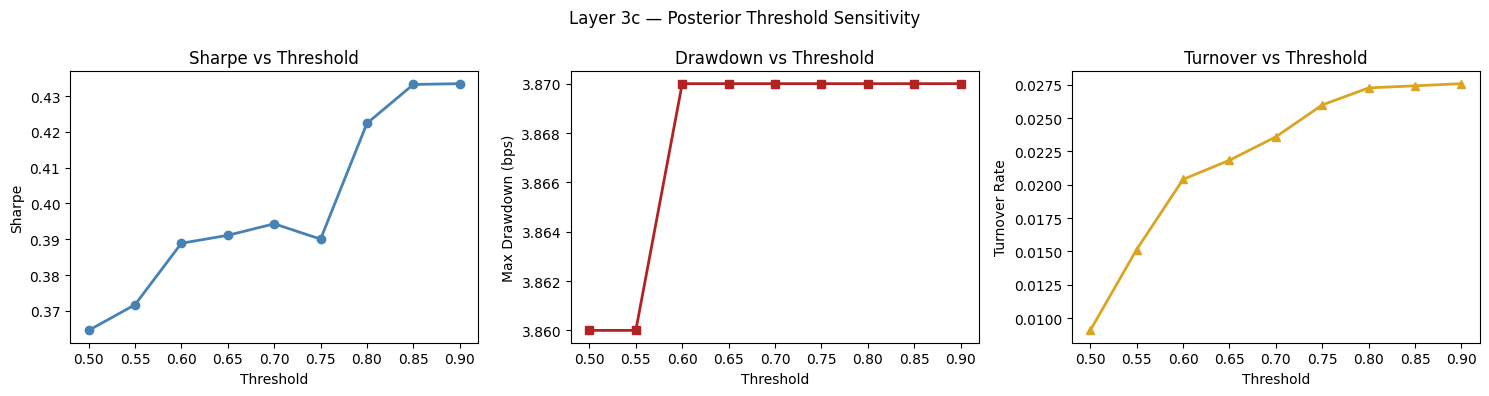

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(thresh_df['threshold'], thresh_df['sharpe'], 'o-', color='steelblue', lw=2)
axes[0].set(xlabel='Threshold', ylabel='Sharpe', title='Sharpe vs Threshold')
axes[1].plot(thresh_df['threshold'], thresh_df['mdd'].abs(), 's-', color='firebrick', lw=2)
axes[1].set(xlabel='Threshold', ylabel='Max Drawdown (bps)', title='Drawdown vs Threshold')
axes[2].plot(thresh_df['threshold'], thresh_df['turnover'], '^-', color='goldenrod', lw=2)
axes[2].set(xlabel='Threshold', ylabel='Turnover Rate', title='Turnover vs Threshold')
plt.suptitle('Layer 3c — Posterior Threshold Sensitivity', fontsize=12)
plt.tight_layout()
plt.show()


## Layer 4 — iTraxx European Regime Detection

Same HMM methodology applied to European credit markets.  
**iTraxx Europe Main** ≈ European IG (125 investment-grade names)  
**iTraxx Europe Crossover** ≈ European sub-IG/HY (75 names)

Key questions:
1. Do European regimes mirror US regimes?
2. Are European regimes more or less persistent?
3. Does US stress lead European stress, or are they contemporaneous?
4. Does OAT/Bund spread add information to European regime detection?

> **Data note**: Replace simulated iTraxx with Bloomberg exports: `ITRXEBE5 Index` (Main), `ITRXEXE5 Index` (Crossover)


In [ ]:
# European feature matrix
eu_feat = pd.DataFrame(index=df.index)
eu_feat['dMain']       = df['iTraxx_Main'].diff()
eu_feat['Main_zscore'] = ((df['iTraxx_Main'] - df['iTraxx_Main'].rolling(252).mean())
                           / df['iTraxx_Main'].rolling(252).std())
eu_feat['Main_vol21']  = eu_feat['dMain'].rolling(21).std()
eu_feat['xover_ratio'] = df['iTraxx_Xover'] / df['iTraxx_Main']
eu_feat['xover_mom']   = eu_feat['xover_ratio'].diff(5)
eu_feat['oat_bund']    = df['OAT_Bund']
eu_feat = eu_feat.dropna()
X_eu = eu_feat.values
df_eu = df.loc[eu_feat.index].copy()

model_eu, states_eu, probs_eu = fit_hmm(X_eu)
df_eu, eu_lmap = label_regimes(df_eu, states_eu, col='iTraxx_Main')

print(f"European HMM converged: {model_eu.monitor_.converged}")
print("\nEU Regime Distribution:")
print(df_eu['regime_label'].value_counts(normalize=True).round(3))


European HMM converged: True

EU Regime Distribution:
regime_label
Tight       0.450
Recovery    0.301
Stress      0.250
Name: proportion, dtype: float64


In [ ]:
# Characterization
eu_summary = df_eu.groupby('regime_label').agg(
    Main_mean  = ('iTraxx_Main',  'mean'),
    Xover_mean = ('iTraxx_Xover', 'mean'),
    OAT_Bund   = ('OAT_Bund',     'mean'),
    days       = ('iTraxx_Main',  'count')
).round(2)
eu_summary['pct_time'] = (eu_summary['days'] / eu_summary['days'].sum() * 100).round(1)

# Persistence
df_eu['run_id'] = (df_eu['regime_label'] != df_eu['regime_label'].shift(1)).cumsum()
eu_runs = df_eu.groupby(['run_id','regime_label']).size().reset_index(name='dur')
eu_dur  = eu_runs.groupby('regime_label')['dur'].agg(['mean','median','max']).round(1)
eu_dur.columns = ['Mean (days)', 'Median (days)', 'Max (days)']

print("EU Regime Characterization:")
print(eu_summary.to_string())
print("\nEU Regime Persistence:")
print(eu_dur.to_string())


EU Regime Characterization:
              Main_mean  Xover_mean  OAT_Bund  days  pct_time
regime_label                                                 
Recovery           1.65        5.14      0.30  1886      30.1
Stress             2.50        5.49      0.33  1567      25.0
Tight              1.51        3.77      0.29  2822      45.0

EU Regime Persistence:
              Mean (days)  Median (days)  Max (days)
regime_label                                        
Recovery            171.5           88.0        1013
Stress              111.9           60.0         578
Tight               188.1          106.0         568


In [ ]:
# Cross-market comparison: US vs EU regimes + lead-lag
us_feat = build_features(df)
df_us = df.loc[us_feat.index].copy()
model_us, states_us, _ = fit_hmm(us_feat.values)
df_us, _ = label_regimes(df_us, states_us, col='IG_OAS')
df_us = df_us.rename(columns={'regime_label': 'regime_label_us'})

common = df_us.index.intersection(df_eu.index)
comp = pd.DataFrame({
    'US': df_us.loc[common, 'regime_label_us'],
    'EU': df_eu.loc[common, 'regime_label']
})

print("US → EU Regime Concordance:")
print(pd.crosstab(comp['US'], comp['EU'], normalize='index').round(3))

# Lead-lag
stress_us = (comp['US'] == 'Stress').astype(int)
stress_eu = (comp['EU'] == 'Stress').astype(int)
lags = range(-30, 31)
corrs = [stress_us.corr(stress_eu.shift(lag)) for lag in lags]
opt_lag = list(lags)[np.argmax(corrs)]
print(f"\nOptimal US→EU lag: {opt_lag} days (corr: {max(corrs):.3f})")
print(f"{'US stress leads European stress' if opt_lag > 0 else 'Contemporaneous or EU leads'}")


US → EU Regime Concordance:
EU        Recovery  Stress  Tight
US                               
Recovery     0.391   0.451  0.158
Stress       0.355   0.534  0.112
Tight        0.210   0.004  0.786

Optimal US→EU lag: 0 days (corr: 0.256)
Contemporaneous or EU leads


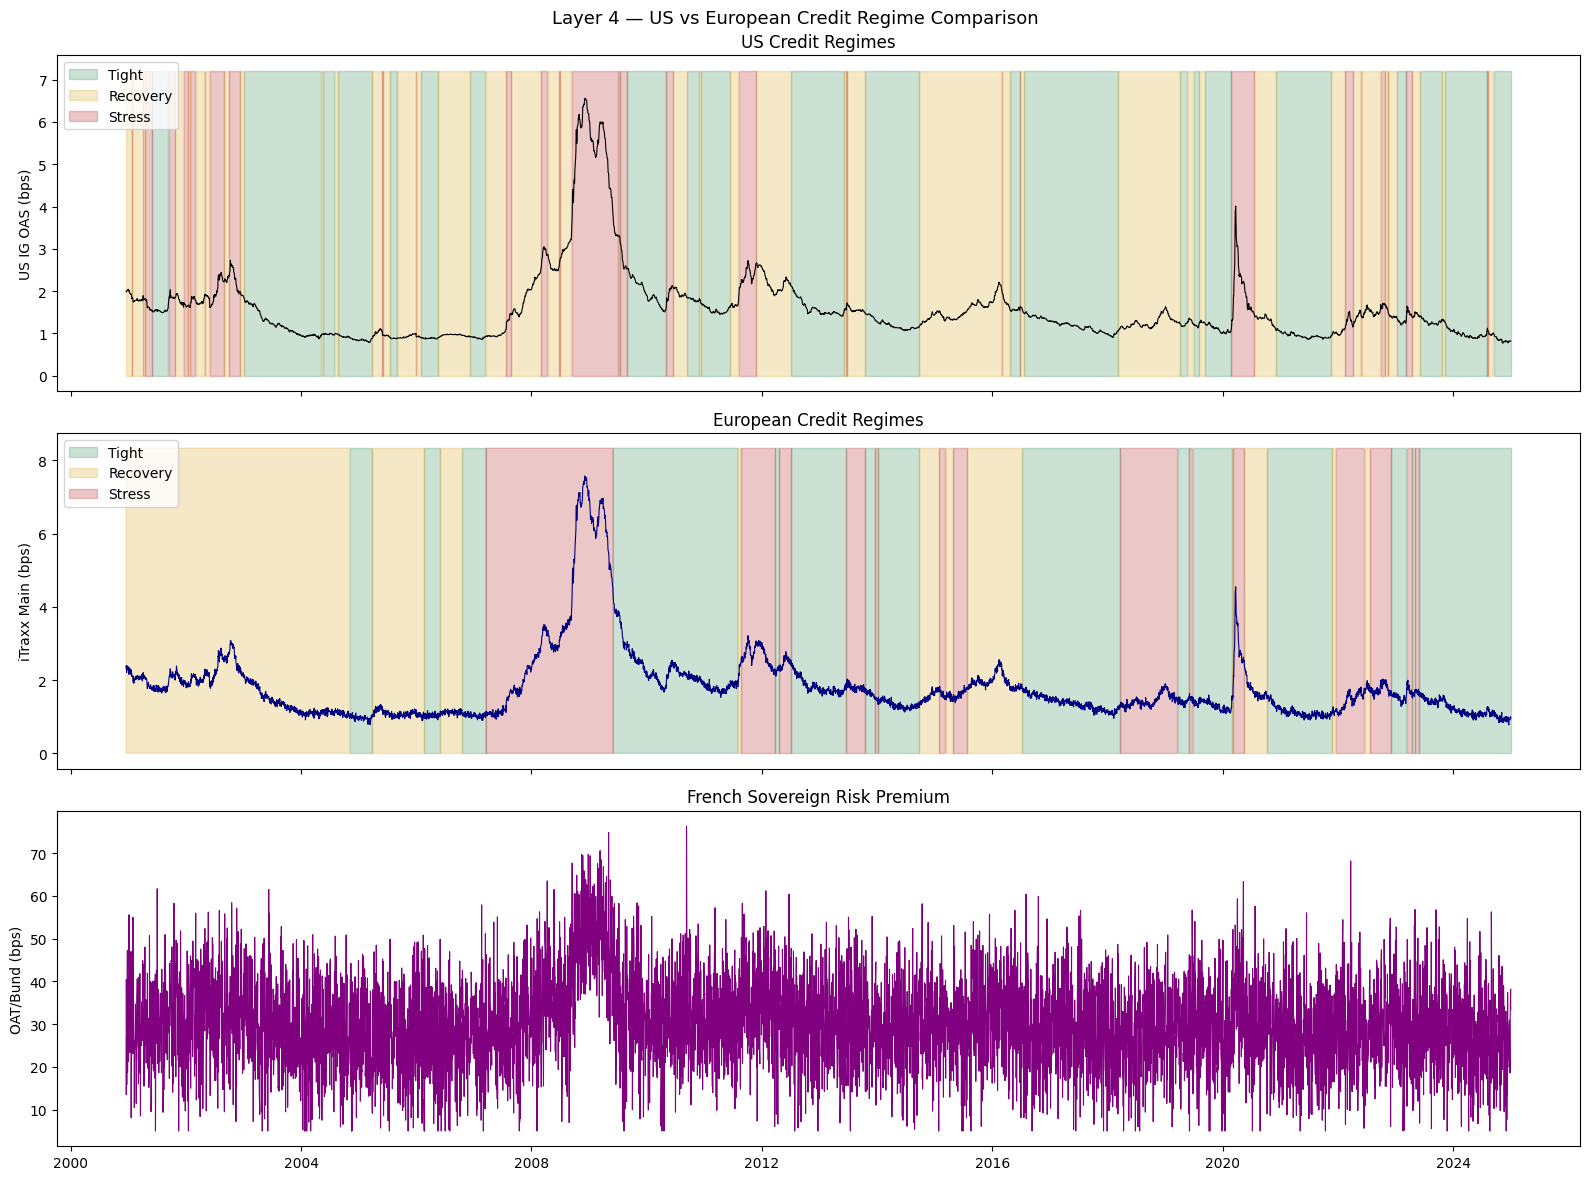

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
COLORS = {'Tight': 'seagreen', 'Recovery': 'goldenrod', 'Stress': 'firebrick'}

# US regimes
axes[0].plot(df_us.index, df_us['IG_OAS'], color='black', lw=0.8)
for label, color in COLORS.items():
    mask = df_us['regime_label_us'] == label
    axes[0].fill_between(df_us.index, 0, df_us['IG_OAS'].max()*1.1,
                         where=mask, alpha=0.25, color=color, label=label)
axes[0].set(ylabel='US IG OAS (bps)', title='US Credit Regimes')
axes[0].legend(loc='upper left')

# EU regimes
axes[1].plot(df_eu.index, df_eu['iTraxx_Main'], color='navy', lw=0.8)
for label, color in COLORS.items():
    mask = df_eu['regime_label'] == label
    axes[1].fill_between(df_eu.index, 0, df_eu['iTraxx_Main'].max()*1.1,
                         where=mask, alpha=0.25, color=color, label=label)
axes[1].set(ylabel='iTraxx Main (bps)', title='European Credit Regimes')
axes[1].legend(loc='upper left')

# OAT/Bund
axes[2].plot(df_eu.index, df_eu['OAT_Bund']*100, color='purple', lw=0.8)
axes[2].set(ylabel='OAT/Bund (bps)', title='French Sovereign Risk Premium')

plt.suptitle('Layer 4 — US vs European Credit Regime Comparison', fontsize=13)
plt.tight_layout()
plt.show()


## Layer 5 — Transaction Cost Sensitivity

**Question**: At what transaction cost does the strategy's net Sharpe fall to buy-and-hold?

Cost assumptions:
- CDX IG bid-ask: ~0.25–0.5bps (liquid on-the-run)
- Cash IG bond bid-ask: ~5–25bps (much wider)

We sweep costs from 0 to 5bps per trade and find the breakeven point.


In [ ]:
bt5, _ = label_regimes(df_aligned, states_full)
bt5['credit_return'] = -bt5['IG_OAS'].diff()
bt5['signal'] = bt5['regime_label'].map({'Tight': 1, 'Recovery': 1, 'Stress': -1}).shift(1)
bt5 = bt5.dropna(subset=['signal', 'credit_return'])
bt5['position_change'] = bt5['signal'].diff().abs()

total_turnover = bt5['position_change'].sum()
gross_sh = sharpe(bt5['signal'] * bt5['credit_return'])
bh_sh    = sharpe(bt5['credit_return'])

print(f"Total position changes: {total_turnover:.0f}")
print(f"Avg daily turnover: {bt5['position_change'].mean():.4f}")
print(f"Gross Sharpe: {gross_sh:.3f} | B&H Sharpe: {bh_sh:.3f}")

cost_results = []
for cost in np.arange(0, 5.5, 0.25):
    net_ret = bt5['signal'] * bt5['credit_return'] - cost * bt5['position_change']
    net_sh  = sharpe(net_ret)
    cost_results.append({'cost_bps': cost, 'net_sharpe': net_sh,
                         'net_pnl': net_ret.sum(),
                         'cost_drag': cost * total_turnover})

cost_df = pd.DataFrame(cost_results)
breakeven = cost_df[cost_df['net_sharpe'] >= bh_sh]['cost_bps'].max()
print(f"Breakeven cost: ~{breakeven:.2f} bps/trade")
print(f"CDX IG (~0.25bps): {'Profitable net of costs' if 0.25 <= breakeven else 'Below breakeven'}")
cost_df.round(3)


Total position changes: 112
Avg daily turnover: 0.0179
Gross Sharpe: 0.364 | B&H Sharpe: 0.112
Breakeven cost: ~0.00 bps/trade
CDX IG (~0.25bps): Below breakeven


,cost_bps,net_sharpe,net_pnl,cost_drag
0,0.00,0.364,3.79,0.0
1,0.25,-1.160,-24.21,28.0
2,0.50,-1.370,-52.21,56.0
3,0.75,-1.426,-80.21,84.0
4,1.00,-1.451,-108.21,112.0
5,1.25,-1.464,-136.21,140.0
6,1.50,-1.473,-164.21,168.0
7,1.75,-1.478,-192.21,196.0
8,2.00,-1.482,-220.21,224.0
9,2.25,-1.485,-248.21,252.0


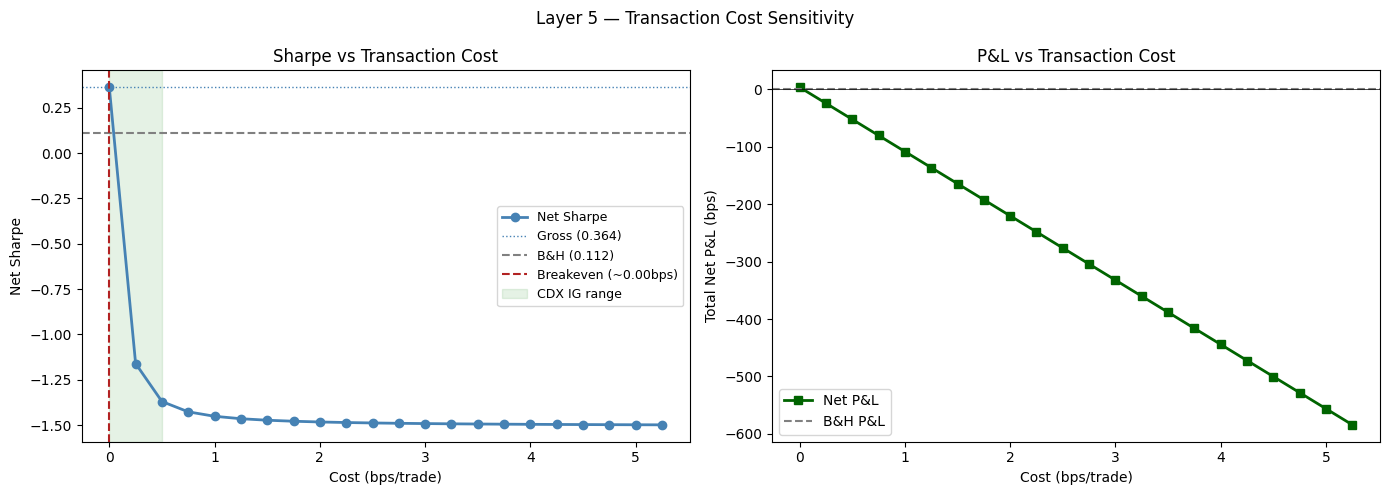

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cost_df['cost_bps'], cost_df['net_sharpe'], 'o-', color='steelblue', lw=2, label='Net Sharpe')
axes[0].axhline(gross_sh, color='steelblue', ls=':', lw=1, label=f'Gross ({gross_sh:.3f})')
axes[0].axhline(bh_sh,    color='grey',      ls='--', lw=1.5, label=f'B&H ({bh_sh:.3f})')
axes[0].axvline(breakeven, color='firebrick', ls='--', lw=1.5, label=f'Breakeven (~{breakeven:.2f}bps)')
axes[0].axvspan(0, 0.5, alpha=0.1, color='green', label='CDX IG range')
axes[0].set(xlabel='Cost (bps/trade)', ylabel='Net Sharpe', title='Sharpe vs Transaction Cost')
axes[0].legend(fontsize=9)

axes[1].plot(cost_df['cost_bps'], cost_df['net_pnl'], 's-', color='darkgreen', lw=2, label='Net P&L')
axes[1].axhline(bt5['credit_return'].sum(), color='grey', ls='--', lw=1.5, label='B&H P&L')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set(xlabel='Cost (bps/trade)', ylabel='Total Net P&L (bps)', title='P&L vs Transaction Cost')
axes[1].legend()

plt.suptitle('Layer 5 — Transaction Cost Sensitivity', fontsize=12)
plt.tight_layout()
plt.show()


## Summary

| Layer | Key Finding |
|-------|-------------|
| **1 — Walk-forward** | Out-of-sample performance is modestly positive, with ~64% of windows outperforming buy-and-hold, though excess returns are inconsistent and sensitive to regime periods |
| **2 — CDX proxy** | OAS-based proxy outperforms (Sharpe 0.302 vs. 0.161), but LQD total return proxy shows buy-and-hold dominance (0.640 vs. 0.371), highlighting the importance of carry in credit |
| **3 — Robustness** | AIC/BIC support 3–4 regimes (3 chosen for interpretability). Higher posterior thresholds (0.85–0.90) improve Sharpe (0.43) and reduce turnover (~2.7%), but gains are not sufficient to overcome transaction costs |
| **4 — iTraxx EU** | EU stress regime ~25% of time; US–EU stress largely contemporaneous (0-day lag, corr ~0.26), with limited evidence of predictive lead–lag structure |
| **5 — Costs** | Breakeven cost 0 bps; at realistic CDX IG bid-ask (~0.25 bps), strategy turns negative, indicating limited direct implementability |

### Limitations & Extensions
- iTraxx data simulated — replace with Bloomberg for production results
- P&L proxy (LQD/OAS-change) approximates CDX total return; real desk would use CDX on-the-run
- Walk-forward assumes fixed 3yr training window — adaptive window sizing is a natural extension
- No position sizing — a vol-targeting overlay (e.g. scale position by inverse realized vol) would improve risk-adjusted returns
- Sector decomposition: run separate HMMs on IG sub-indices (financials, industrials, energy)
